In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')

#1. Load Data

In [43]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Crop_recommendation.csv')
print(df.shape)
df.head()

(2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


#2. Identify Data Types

In [44]:
dtype_df = pd.DataFrame({'dtype': df.dtypes.astype(str),'n_unique': df.nunique()})
dtype_df['data_category'] = np.where(dtype_df['dtype'].isin(['int64','float64']), 'Numerical','Categorical')
dtype_df

,dtype,n_unique,data_category
N,int64,137,Numerical
P,int64,117,Numerical
K,int64,73,Numerical
temperature,float64,2200,Numerical
humidity,float64,2200,Numerical
ph,float64,2200,Numerical
rainfall,float64,2200,Numerical
label,object,22,Categorical


In [45]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [46]:
print('Numerical columns: ',df.select_dtypes(include='number').columns.tolist())
print('Categorical columns: ',df.select_dtypes(include='object').columns.tolist())

Numerical columns:  ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Categorical columns:  ['label']


#3. Stats

In [47]:
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


#4. Missing Values Handling

In [48]:
missing=df.isnull().sum()
missing_pct=(missing/len(df)*100).round(2)
missing_df=pd.DataFrame({'missing_count':missing,'missing_pct':missing_pct})
missing_df[missing_df['missing_count']>0].sort_values('missing_pct',ascending=False)

,missing_count,missing_pct


No missing value

#5. Identify duplicates

In [49]:
dupe_incl_id=df.duplicated().sum()
print('Duplicate rows: ',dupe_incl_id)

Duplicate rows:  0


#6. Outliers Handling

In [50]:
def iqr_outliers(series):
  q1, q3 = series.quantile([0.25, 0.75])
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  n_out = (~series.between(lower_bound, upper_bound)).sum()
  return (n_out, lower_bound, upper_bound)

for col in numeric_cols:
  n_out, low, up = iqr_outliers(df[col])
  print(f'{col}: {n_out} outliers (valid range ~[{low:.2f},{up:.2f}])')

N: 0 outliers (valid range ~[-73.88,179.12])
P: 138 outliers (valid range ~[-32.00,128.00])
K: 200 outliers (valid range ~[-23.50,92.50])
temperature: 86 outliers (valid range ~[14.08,37.25])
humidity: 30 outliers (valid range ~[15.73,134.48])
ph: 57 outliers (valid range ~[4.54,8.35])
rainfall: 100 outliers (valid range ~[-25.02,213.84])


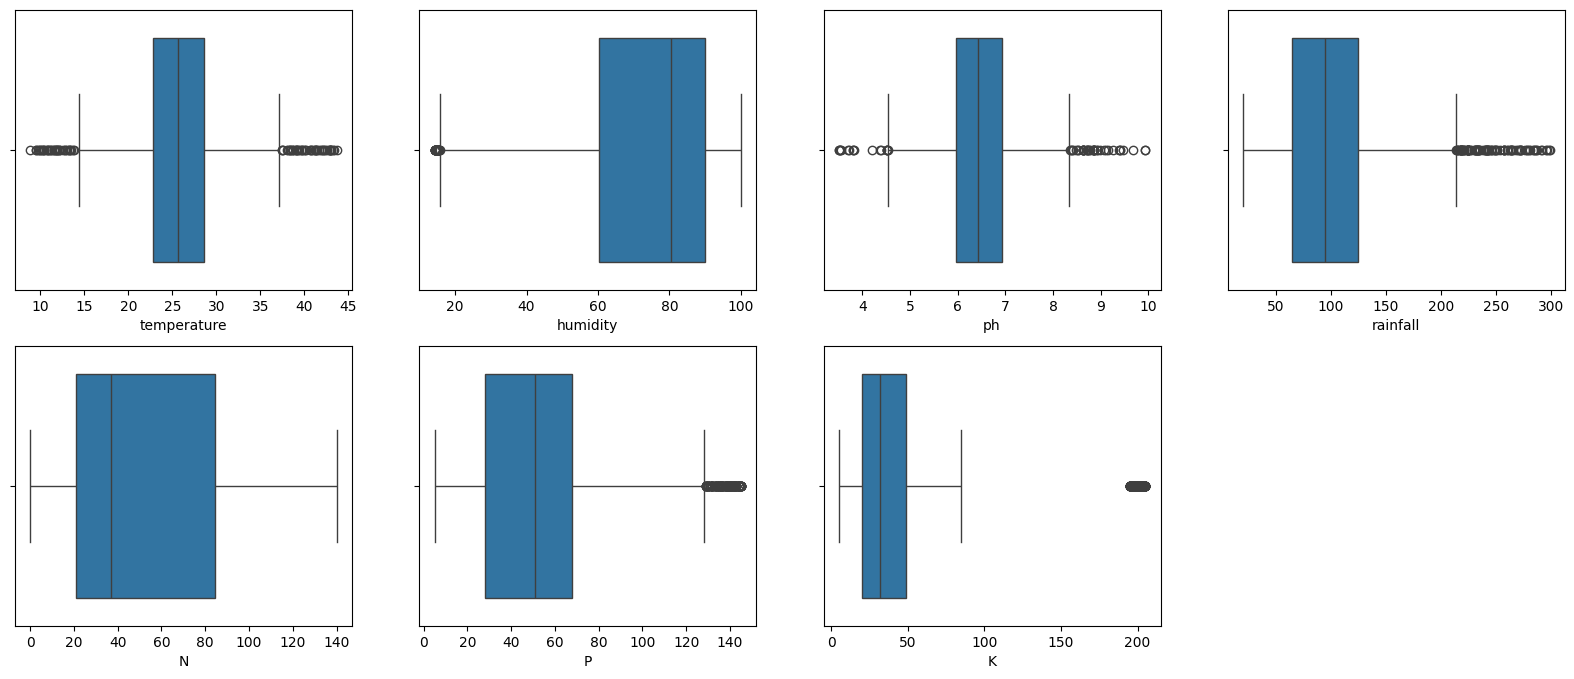

In [51]:
fig,axes=plt.subplots(2,4,figsize=(20,8))
sns.boxplot(x=df['temperature'],ax=axes[0,0])
sns.boxplot(x=df['humidity'], ax=axes[0,1])
sns.boxplot(x=df['ph'], ax=axes[0,2])
sns.boxplot(x=df['rainfall'], ax=axes[0,3])
sns.boxplot(x=df['N'], ax=axes[1,0])
sns.boxplot(x=df['P'], ax=axes[1,1])
sns.boxplot(x=df['K'], ax=axes[1,2])
fig.delaxes(axes[1,3])
plt.show()

#7. EDA

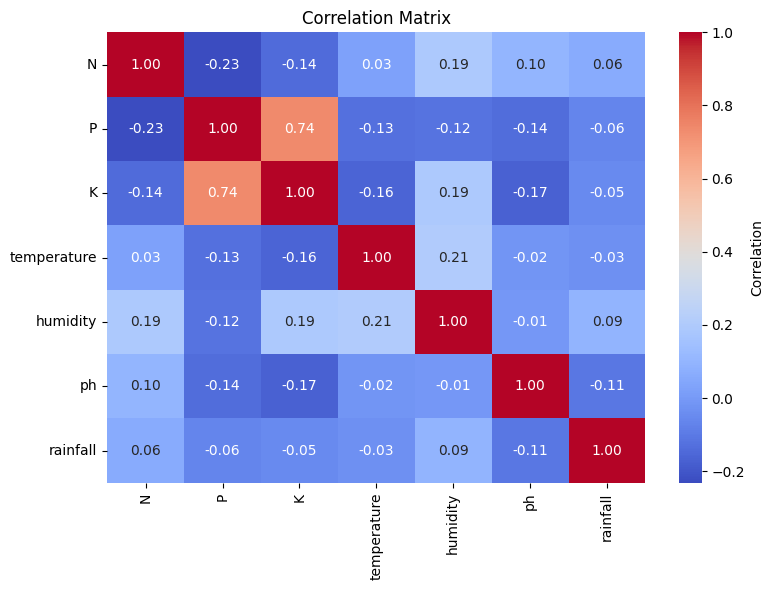

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm',fmt='.2f',cbar_kws={'label':'Correlation'})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

#8. Train test Split

In [53]:
dff=df.copy()
X=dff.drop('label',axis=1)
Y=dff['label']
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print('Training set size:', x_train.shape[0])
print('Test set size:', x_test.shape[0])
print('\nTrain features:', x_train.shape)
print('Test features :', x_test.shape)

Training set size: 1760
Test set size: 440

Train features: (1760, 7)
Test features : (440, 7)


#9. Preprocessing: Scaling & Encoding

In [54]:
preprocessing_pipeline = Pipeline([
    ('scaler', RobustScaler())
])

x_train_processed = preprocessing_pipeline.fit_transform(x_train)
x_test_processed = preprocessing_pipeline.transform(x_test)

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


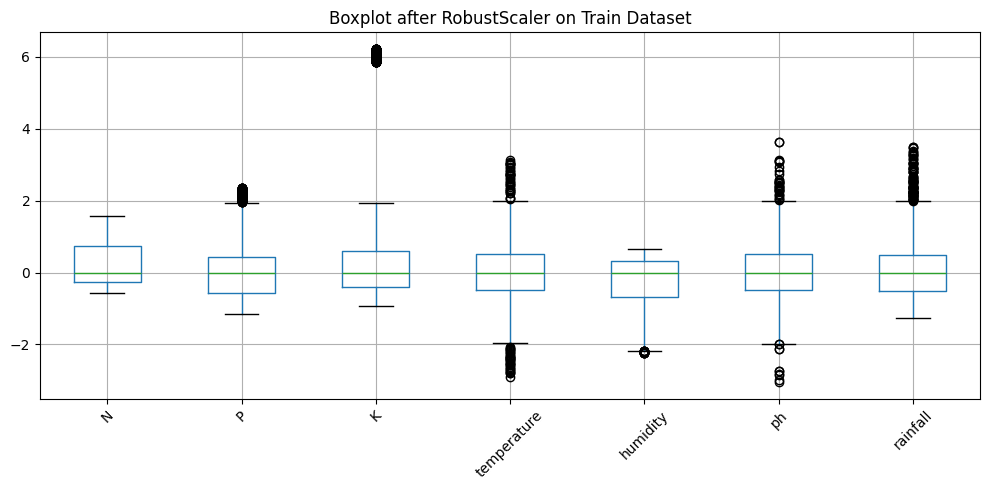

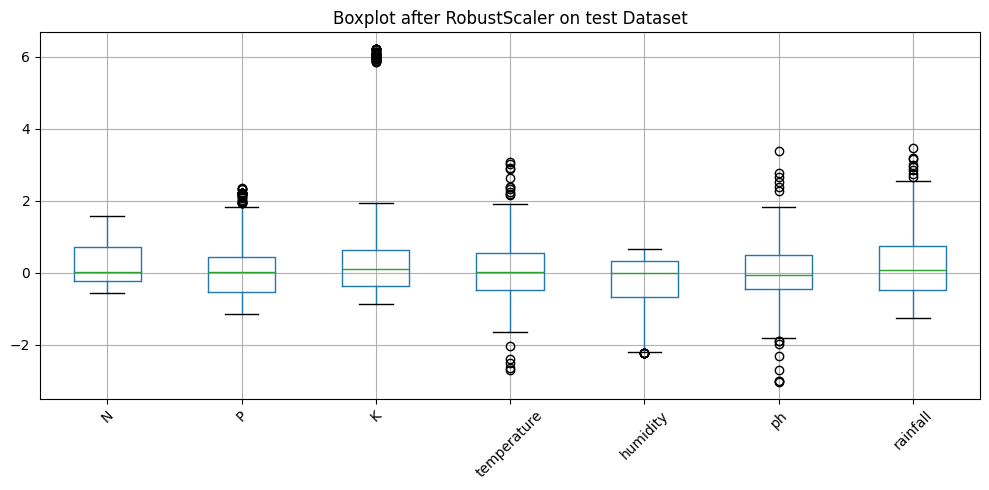

In [55]:
x_train_processed_df = pd.DataFrame(x_train_processed, columns=x_train.columns)
x_test_processed_df = pd.DataFrame(x_test_processed, columns=x_test.columns)
plt.figure(figsize=(10,5))
x_train_processed_df.boxplot(rot=45)
plt.title('Boxplot after RobustScaler on Train Dataset')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,5))
x_test_processed_df.boxplot(rot=45)
plt.title('Boxplot after RobustScaler on test Dataset')
plt.tight_layout()
plt.show()


#9. Model building

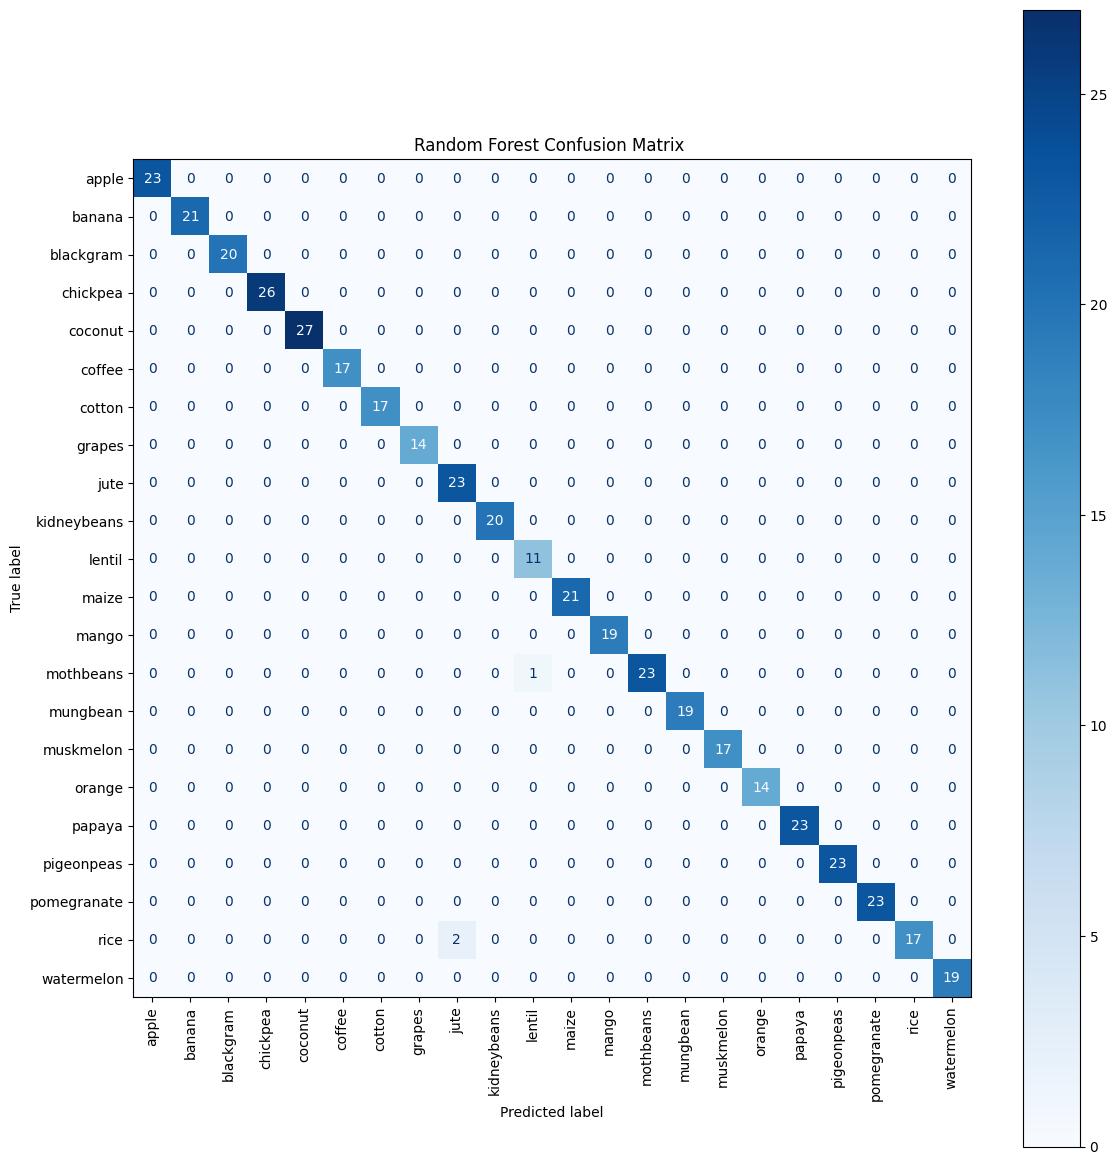

CLASSIFICATION_REPORT               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        14
     

In [56]:
model=RandomForestClassifier(random_state=43)
model.fit(x_train_processed,y_train_encoded
)
prediction=model.predict(x_test_processed_df)
cm=confusion_matrix(y_test_encoded,prediction)
cm_display=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=encoder.classes_)
fig, ax = plt.subplots(figsize=(12, 12))
cm_display.plot(ax=ax, xticks_rotation='vertical', cmap='Blues')
plt.title('Random Forest Confusion Matrix ')
plt.tight_layout()
plt.show()
print("CLASSIFICATION_REPORT",classification_report(y_test_encoded,prediction))
readable_prediction = encoder.inverse_transform(prediction)
print(readable_prediction)

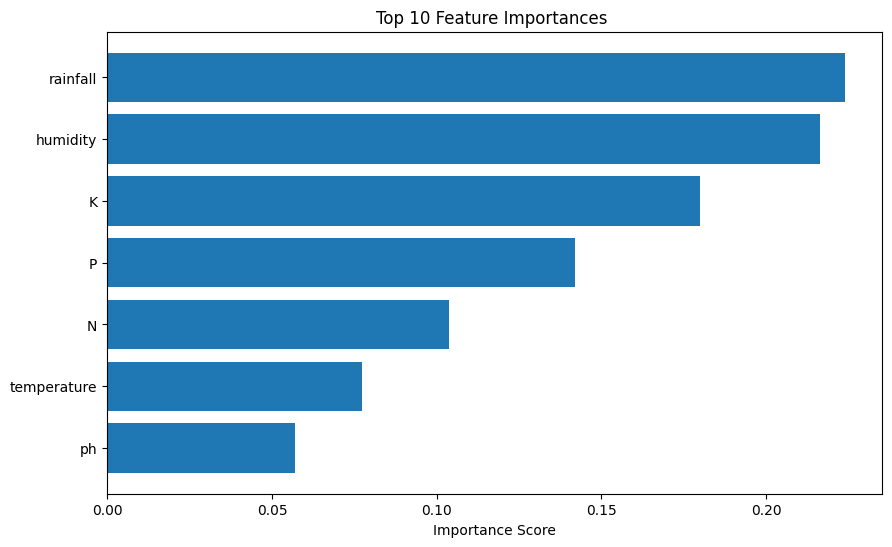

    Feature  Importance
6  rainfall    0.224001
4  humidity    0.216278
2         K    0.179882
1         P    0.141828
0         N    0.103853


In [57]:
importances = model.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': x_train_processed_df.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10][::-1], feature_importance_df['Importance'][:10][::-1])
plt.title('Top 10 Feature Importances ')
plt.xlabel('Importance Score')
plt.show()


print(feature_importance_df.head())

# 10-To ensure model is generalized

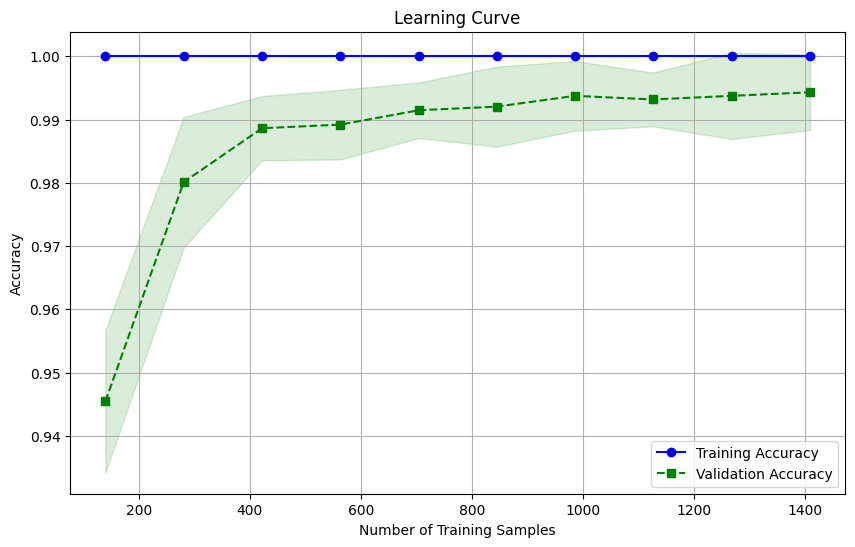

In [58]:


train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=x_train_processed,
    y=y_train_encoded,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)


train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))


plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Training Accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='green')

plt.title('Learning Curve')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# FOR USER

In [59]:

amount_of_nitrogen=int(input("Enter the amount of nitrogen(N)[0-140]: "))
amount_of_phosphorous=int(input("Enter the amount of phosphorous(P)[5-145]: "))
amount_of_potassium=int(input("Enter the amount of potassium(K)[5-205]:"))
Temperature=float(input("Enter the temperature(C): "))
humidity=float(input("Enter the humidity:"))
ph=float(input("Enter the ph[3-10]: "))
rainfall=float(input("Enter the rainfall(mm)[20-300]: "))
min_confidence = float(input("Enter the minimum confidence [default 10]: ") or 10)

user_input=pd.DataFrame({
    'N':[amount_of_nitrogen],
    'P':[amount_of_phosphorous],
    'K':[amount_of_potassium],
    'temperature':[Temperature],
    'humidity':[humidity],
    'ph':[ph],
    'rainfall':[rainfall]
})

user_input_processed = preprocessing_pipeline.transform(user_input)

probabilities = model.predict_proba(user_input_processed)[0]

crop_names = encoder.classes_
top_idx = np.argsort(probabilities)[::-1]

print("Top Recommended Crops:\n")
for rank, idx in enumerate(top_idx, start=1):
    crop = crop_names[idx]
    confidence = probabilities[idx] * 100
    if confidence < min_confidence:
        break
    print(f"{rank}. {crop:<15} — {confidence:.2f}% match")

Enter the amount of nitrogen(N)[0-140]: 10
Enter the amount of phosphorous(P)[5-145]: 5
Enter the amount of potassium(K)[5-205]:8
Enter the temperature(C): 24
Enter the humidity:142
Enter the ph[3-10]: 7
Enter the rainfall(mm)[20-300]: 40
Enter the minimum confidence [default 10]: 
[15  7  3 13  1]
Top Recommended Crops:

1. orange          — 56.00% match
2. mungbean        — 15.00% match
3. watermelon      — 10.00% match


In [60]:
import joblib
import sklearn
import pandas as np_check
import numpy
import sys
from google.colab import files

joblib.dump(model, 'crop_model.pkl')
joblib.dump(preprocessing_pipeline, 'preprocessing_pipeline.pkl')
joblib.dump(encoder, 'label_encoder.pkl')

print("Saved: crop_model.pkl, preprocessing_pipeline.pkl, label_encoder.pkl")

print("\n--- Versions used in this Colab session ---")
print(f"python        : {sys.version.split()[0]}")
print(f"scikit-learn  : {sklearn.__version__}")
print(f"pandas        : {pd.__version__}")
print(f"numpy         : {numpy.__version__}")
print(f"joblib        : {joblib.__version__}")


requirements_content = f"""
pandas=={pd.__version__}
numpy=={numpy.__version__}
scikit-learn=={sklearn.__version__}
joblib=={joblib.__version__}
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print("\nGenerated requirements.txt:")
print(requirements_content)

files.download('crop_model.pkl')
files.download('preprocessing_pipeline.pkl')
files.download('label_encoder.pkl')
files.download('requirements.txt')

Saved: crop_model.pkl, preprocessing_pipeline.pkl, label_encoder.pkl

--- Versions used in this Colab session ---
python        : 3.13.15
scikit-learn  : 1.6.1
pandas        : 2.2.3
numpy         : 2.1.3
joblib        : 1.5.3

Generated requirements.txt:

pandas==2.2.3
numpy==2.1.3
scikit-learn==1.6.1
joblib==1.5.3



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>